In [34]:
import pandas as pd
import numpy as np
from skimpy import skim
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.float_format", lambda x: f"{x :.2f}")
pd.set_option("display.max_columns", None)

In [35]:
url = "https://raw.githubusercontent.com/MaskiVal/DataSets/main/heartDisease.csv"
df = pd.read_csv(url)
df.drop_duplicates(inplace=True)
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.60,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.20,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.20,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.40,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.20,1,1,3,0


# Analyse exploratoire, traitements

In [36]:
# df.to_csv("Maladies_Cardiaques.csv")
# df = pd.read_csv("Maladies_Cardiaques.csv", sep = ",")
# df.drop(columns=['Unnamed: 0'], inplace=True)
# df = df.reset_index().rename(columns={'index': 'id'})

In [37]:
display(df.head())
display(df.shape)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.60,2,0,2,1


(302, 14)

## 1 - Exploration des données

#### 1.1.1 - Nombre de données, visualisation des colonnes du dataset

In [38]:
# df.to_csv("Maladies_Cardiaques")
# link = 'https://raw.githubusercontent.com/MaskiVal/DataSets/main/heartDisease.csv'
# df = pd.read_csv(link, sep = ",")

In [39]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [40]:
'''
| Nom de la colonne | Définition                      | Explication de la variable                      |
|-------------------|---------------------------------|-------------------------------------------------|
| age               | Âge du patient                  | L'âge est utilisé pour évaluer le risque.       |
| sex               | Sexe du patient                 | 1 pour masculin, 0 pour féminin.                |
| cp                | Type de douleur thoracique      | 4 valeurs possibles, de 1 à 4.                  |
| trestbps          | Pression artérielle au repos    | Mesurée en mm Hg au moment de l'admission.      |
| chol              | Cholestérol sérique             | Mesuré en mg/dl.                                |
| fbs               | Glycémie à jeun                 | 1 si > 120 mg/dl, 0 sinon.                      |
| restecg           | Résultats électrocardiographiques au repos | 0 = normal; 1 = ayant des anomalies ST-T; 2 = montrant une hypertrophie ventriculaire probable ou certaine. |
| thalach           | Fréquence cardiaque maximale atteinte | Mesurée en battements par minute.             |
| exang             | Angine induite par l'exercice   | 1 = oui; 0 = non.                               |
| oldpeak           | Dépression du segment ST induite par l'exercice par rapport au repos | Mesurée en mm.        |
| slope             | Pente du segment ST d'exercice  | 1 = montant; 2 = plat; 3 = descendant.          |
| ca                | Nombre de vaisseaux principaux colorés par fluoroscopie | 0-4 vaisseaux.         |
| thal              | Thalassémie                     | 3 = normal; 6 = défaut fixe; 7 = défaut réversible. |
| target            | Diagnostic de maladie cardiaque | 1 = maladie; 0 = pas de maladie.
'''

"\n| Nom de la colonne | Définition                      | Explication de la variable                      |\n|-------------------|---------------------------------|-------------------------------------------------|\n| age               | Âge du patient                  | L'âge est utilisé pour évaluer le risque.       |\n| sex               | Sexe du patient                 | 1 pour masculin, 0 pour féminin.                |\n| cp                | Type de douleur thoracique      | 4 valeurs possibles, de 1 à 4.                  |\n| trestbps          | Pression artérielle au repos    | Mesurée en mm Hg au moment de l'admission.      |\n| chol              | Cholestérol sérique             | Mesuré en mg/dl.                                |\n| fbs               | Glycémie à jeun                 | 1 si > 120 mg/dl, 0 sinon.                      |\n| restecg           | Résultats électrocardiographiques au repos | 0 = normal; 1 = ayant des anomalies ST-T; 2 = montrant une hypertrophie ve

#### 1.1.2 - Observation des types de données

In [41]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 302    │ │ int32       │ 13    │                                                          │
│ │ Number of columns │ 14     │ │ float64     │ 1     │                                                          │
│ └───────────────────┴────────┘ └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━┓  │
│ ┃ column_name     ┃ NA  ┃ NA %   ┃ mean     ┃ sd       ┃ p0   ┃ p25     ┃ p50     ┃ p75    ┃ p100  ┃ hist    ┃  │
│ ┡━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━┩  │
│ │ age             │   0 │      0 │    54.42 │    9.048 │   29 │      48 │    55.5 │     61 │    77 │ ▁▃▅▇▅▁  │  │
│ │ sex             │   0 │      0 │   0.6821 │   0.4664 │    0 │       0 │       1 │      1 │     1 │ ▃    ▇  │  │
│ │ cp              │   0 │      0 │   0.9636 │    1.032 │    0 │       0 │       1 │      2 │     3 │ ▇ ▃ ▅▁  │  │
│ │ trestbps        │   0 │      0 │    131.6 │    17.56 │   94 │     120 │     130 │    140 │   200 │  ▃▇▇▃▁  │  │
│ │ chol            │   0 │      0 │    246.5 │    51.75 │  126 │     211 │   240.5 │  274.8 │   564 │   ▂▇▃   │  │
│ │ fbs             │   0 │      0 │    0.149 │   0.3567 │    0 │       0 │       0 │      0 │     1 │ ▇    ▁  │  │
│ │ restecg         │   0 │      0 │   0.5265 │    0.526 │    0 │       0 │       1 │      1 │     2 │  ▇  ▇   │  │
│ │ thalach         │   0 │      0 │    149.6 │     22.9 │   71 │   133.2 │   152.5 │    166 │   202 │  ▂▃▇▇▁  │  │
│ │ exang           │   0 │      0 │   0.3278 │   0.4702 │    0 │       0 │       0 │      1 │     1 │ ▇    ▃  │  │
│ │ oldpeak         │   0 │      0 │    1.043 │    1.161 │    0 │       0 │     0.8 │    1.6 │   6.2 │  ▇▃▁▁   │  │
│ │ slope           │   0 │      0 │    1.397 │   0.6163 │    0 │       1 │       1 │      2 │     2 │ ▁  ▇ ▇  │  │
│ │ ca              │   0 │      0 │   0.7185 │    1.007 │    0 │       0 │       0 │      1 │     4 │  ▇▃ ▂▁  │  │
│ │ thal            │   0 │      0 │    2.315 │    0.613 │    0 │       2 │       2 │      3 │     3 │   ▁ ▇▆  │  │
│ │ target          │   0 │      0 │    0.543 │    0.499 │    0 │       0 │       1 │      1 │     1 │ ▇    ▇  │  │
│ └─────────────────┴─────┴────────┴──────────┴──────────┴──────┴─────────┴─────────┴────────┴───────┴─────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 302 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 35.4 KB


### 1.2 - Observation des variables numériques

#### 1.2.1 - Analyse de la distribution

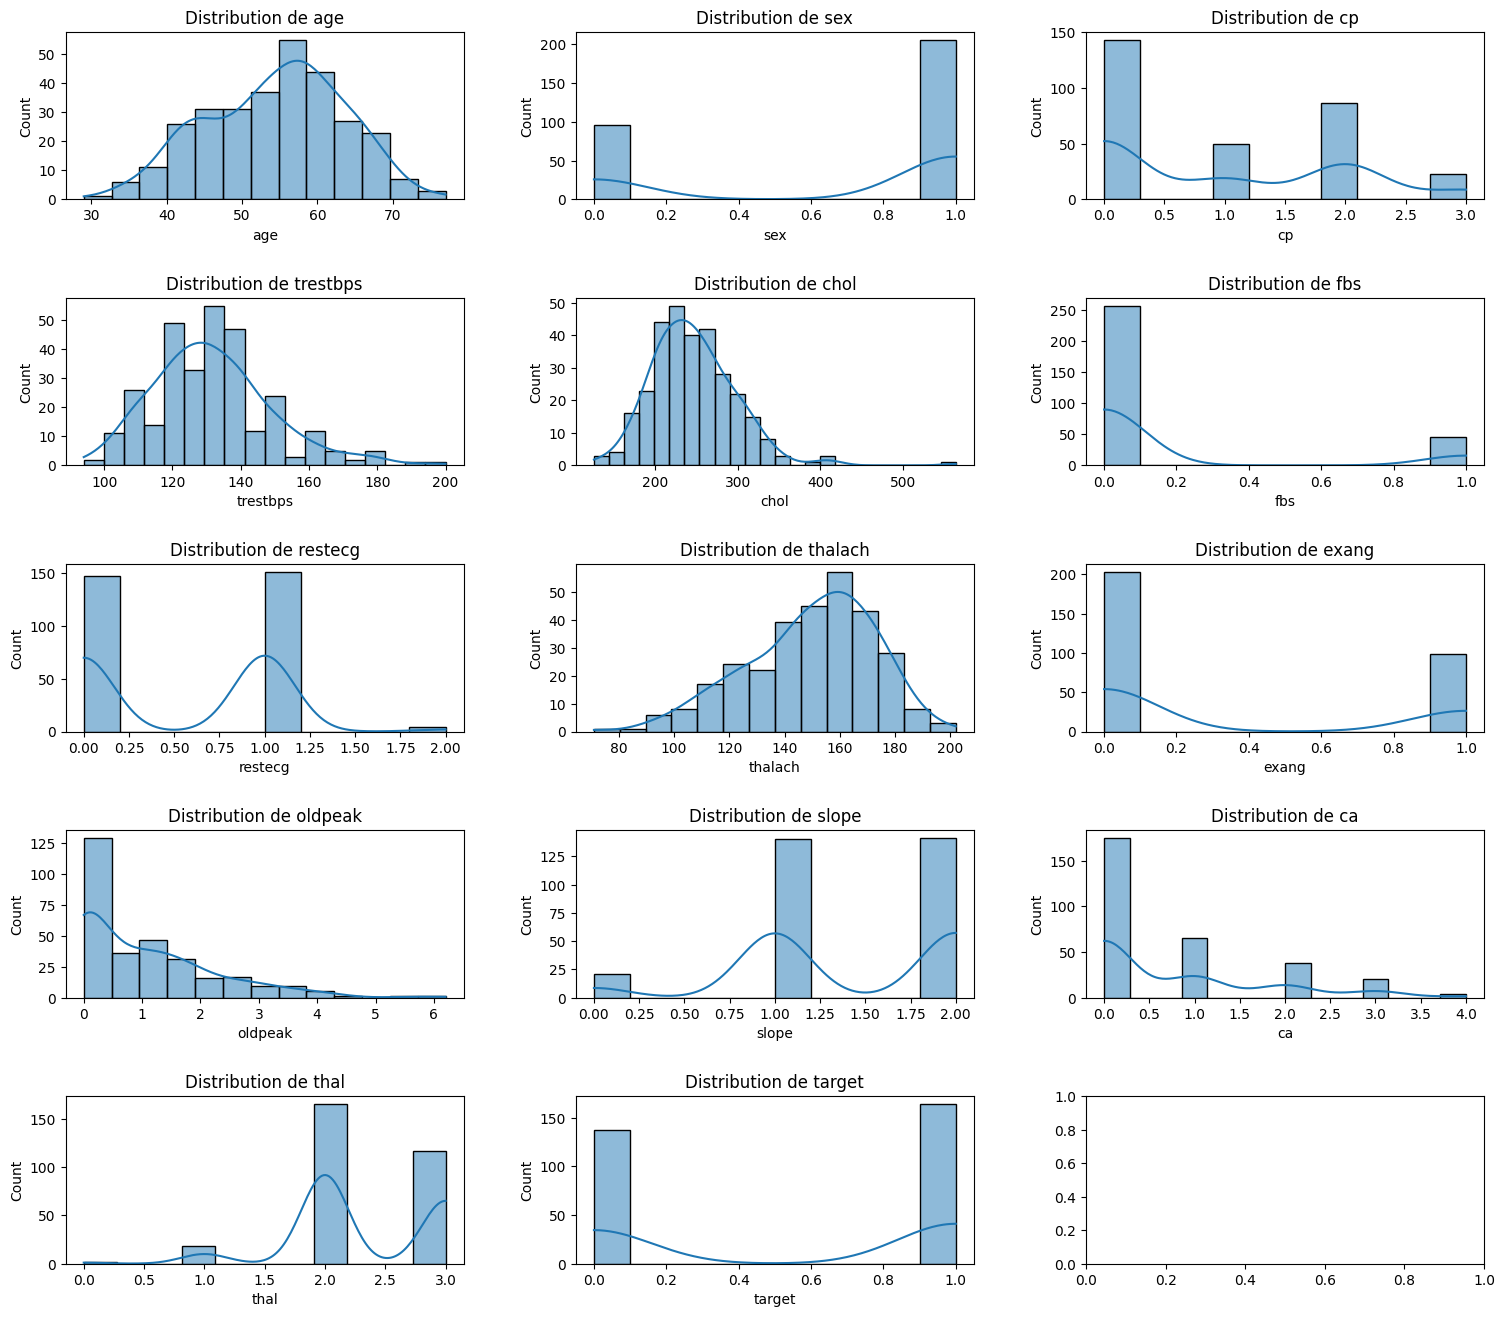

In [43]:
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(16, 14))
fig.tight_layout(pad=5.0)
columns = df.columns
for ax, col in zip(axes.flatten(), columns):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'Distribution de {col}')
plt.show()

#### 1.2.2 - Analyse statique descriptive de base

In [44]:
df["target"].value_counts()

target
1    164
0    138
Name: count, dtype: int64

### 1.3 - Observation des variables catégoritielles

#### 1.3.1 - Analyse du nombre de valeurs unique

In [45]:
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

#### 1.3.2 - Analyse des  statistique de base

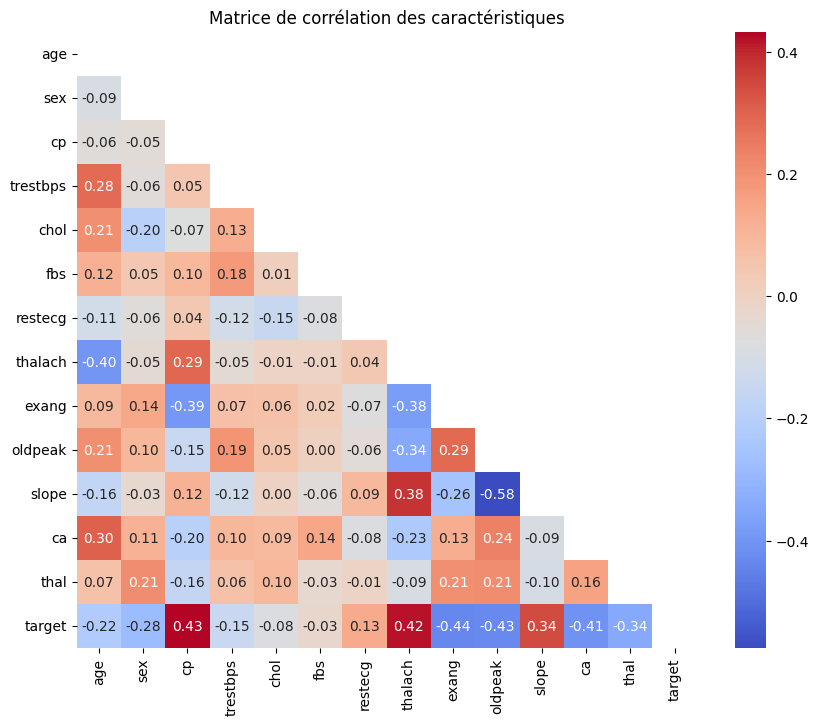

In [46]:
plt.figure(figsize=(10, 8))

# Calculer la matrice de corrélation
corr_matrix = df.corr()
# Créer le masque à partir de la matrice de corrélation
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', mask=mask)
plt.title('Matrice de corrélation des caractéristiques')
plt.show()


## 2 - Nettoyage des données

### 2.1 - Traitement des valeurs manquantes

In [47]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### 2.2 - Traitement des doublons

In [48]:
df[df.duplicated(keep=False)]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target


### 2.3 - Traitement des valeurs abérantes

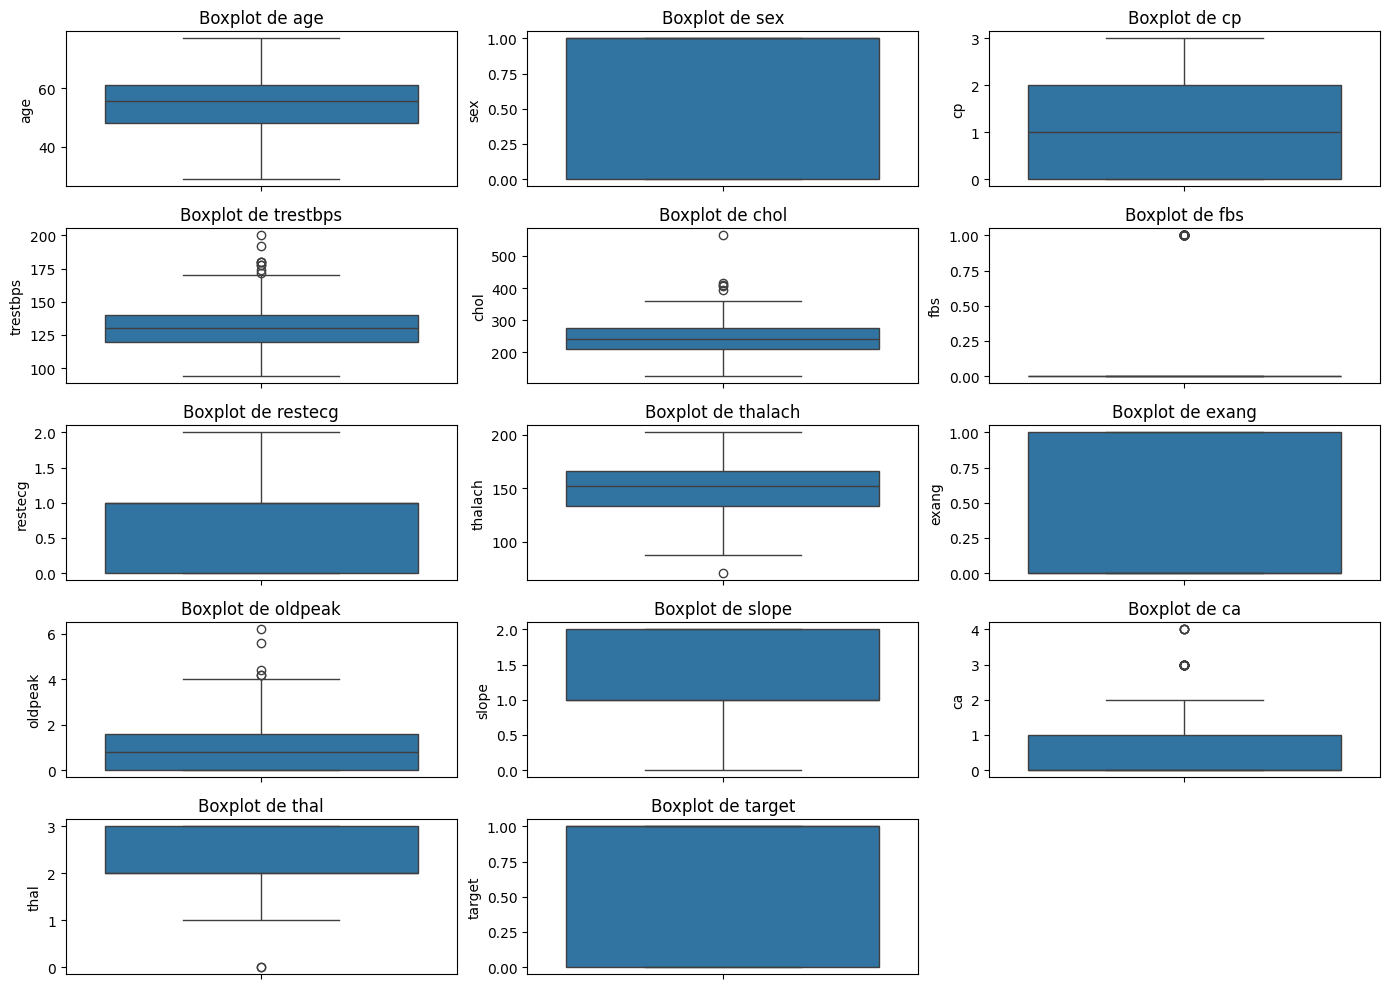

In [49]:
colonnes_numeriques = df.select_dtypes(include=['number']).columns
plt.figure(figsize=(14, 10))  # Vous pouvez ajuster la taille globale ici
for i, col in enumerate(colonnes_numeriques):
    plt.subplot(len(colonnes_numeriques) // 3 + 1, 3, i + 1)  # Organise les plots en grille
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()


In [50]:
# from ydata_profiling import ProfileReport
# profile = ProfileReport(df, title="Report")
# profile

## 3 - Validation statistique pour l'interpretabilité des résultats

### 3.1 - Distribution en fonction de target

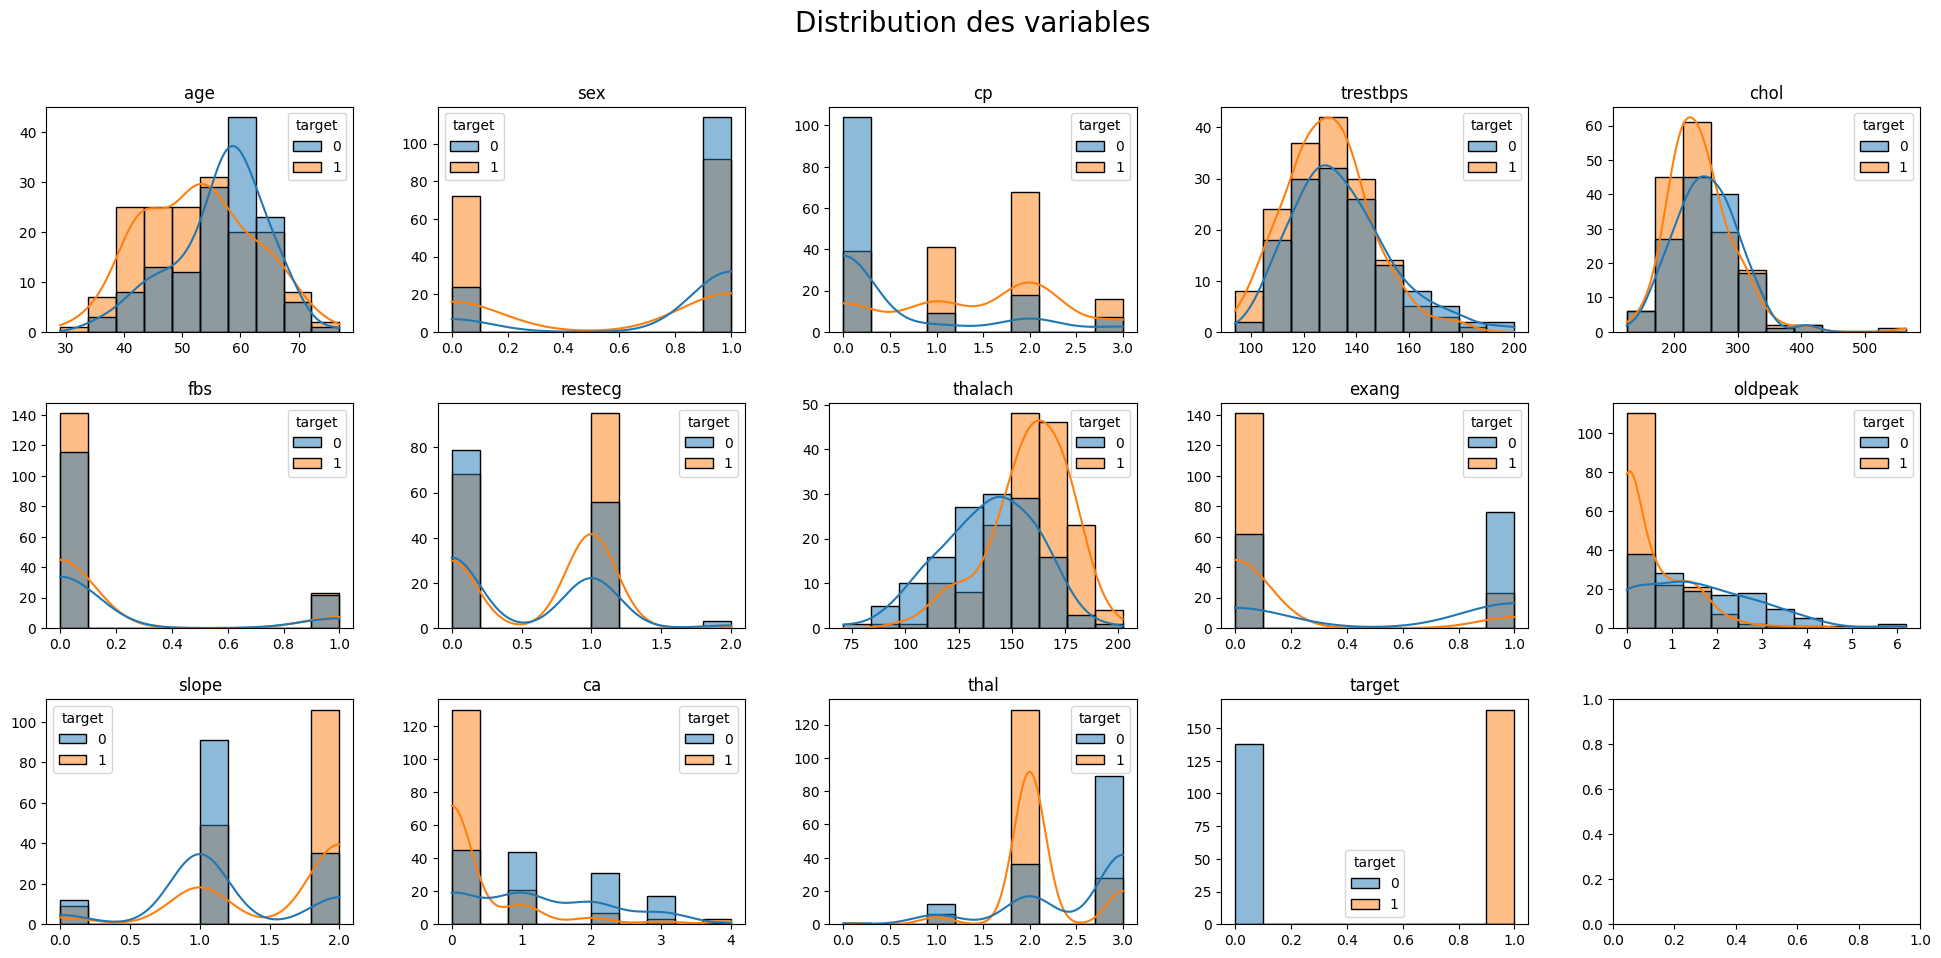

"\n# Crée une figure avec une grille de sous-graphiques de 3 lignes et 5 colonnes, de taille 20x10 pouces\nfig, axes = plt.subplots(3, 5, figsize=(20, 10))\n\n# Ajoute un titre à la figure\nfig.suptitle('Distribution des variables', fontsize=20)\n\n# Ajuste l'espacement entre les sous-graphiques\nfig.tight_layout(pad=3.0)\n\n# Itère sur les colonnes du DataFrame df à partir de la deuxième colonne\nfor i, col in enumerate(df[1:]):\n    # Trace un histogramme pour la colonne col en fonction de la variable cible 'target'\n    # Utilise la méthode 'sturges' pour déterminer le nombre de bacs\n    # Affiche une estimation de la densité (kde) et place le graphique dans le sous-graphique correspondant\n    sns.histplot(df, x=col, hue='target', bins='sturges', kde=True, ax=axes[i//5, i%5])\n\n    # Définit le titre du sous-graphique comme le nom de la colonne\n    axes[i//5, i%5].set_title(col)\n\n    # Supprime les étiquettes de l'axe x et y\n    axes[i//5, i%5].set_xlabel('')\n    axes[i//5, 

In [51]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
fig.suptitle('Distribution des variables', fontsize=20)
fig.tight_layout(pad=3.0)

for i, col in enumerate(df[1:]):
    sns.histplot(df, x=col, hue='target', bins='sturges', kde=True, ax=axes[i//5, i%5])
    axes[i//5, i%5].set_title(col)
    axes[i//5, i%5].set_xlabel('')
    axes[i//5, i%5].set_ylabel('')

plt.show()

'''
# Crée une figure avec une grille de sous-graphiques de 3 lignes et 5 colonnes, de taille 20x10 pouces
fig, axes = plt.subplots(3, 5, figsize=(20, 10))

# Ajoute un titre à la figure
fig.suptitle('Distribution des variables', fontsize=20)

# Ajuste l'espacement entre les sous-graphiques
fig.tight_layout(pad=3.0)

# Itère sur les colonnes du DataFrame df à partir de la deuxième colonne
for i, col in enumerate(df[1:]):
    # Trace un histogramme pour la colonne col en fonction de la variable cible 'target'
    # Utilise la méthode 'sturges' pour déterminer le nombre de bacs
    # Affiche une estimation de la densité (kde) et place le graphique dans le sous-graphique correspondant
    sns.histplot(df, x=col, hue='target', bins='sturges', kde=True, ax=axes[i//5, i%5])

    # Définit le titre du sous-graphique comme le nom de la colonne
    axes[i//5, i%5].set_title(col)

    # Supprime les étiquettes de l'axe x et y
    axes[i//5, i%5].set_xlabel('')
    axes[i//5, i%5].set_ylabel('')

# Affiche la figure contenant tous les sous-graphiques
plt.show()
'''

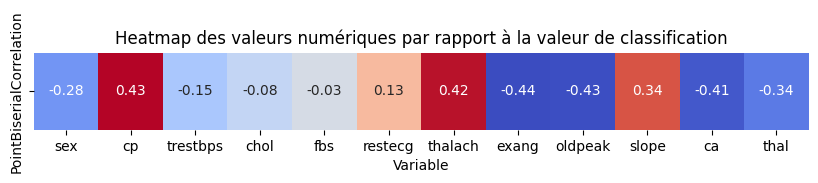

In [52]:
from scipy.stats import kruskal, pointbiserialr
continuous_cols = df.iloc[:,1:-1]

# Calculer la corrélation bisériale ponctuelle pour chaque variable continue
correlations = {}
for col in continuous_cols.columns:
    correlations[col] = pointbiserialr(df['target'], df[col])[0]

# Convertir le dictionnaire en DataFrame pour la heatmap
corr_df = pd.DataFrame(list(correlations.items()), columns=['Variable', 'PointBiserialCorrelation'])
corr_df.set_index('Variable', inplace=True)

plt.figure(figsize=(10, 1))
sns.heatmap(corr_df.T, annot=True, cmap='coolwarm', cbar=False, fmt=".2f")
plt.title('Heatmap des valeurs numériques par rapport à la valeur de classification')
plt.show()

In [53]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Ajouter une colonne constante pour calculer le VIF
X_vif = add_constant(df.drop(["target"], axis=1))

# Calculer le VIF pour chaque variable
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data

,Variable,VIF
0,const,206.85
1,age,1.45
2,sex,1.16
3,cp,1.29
4,trestbps,1.18
5,chol,1.15
6,fbs,1.09
7,restecg,1.06
8,thalach,1.61
9,exang,1.40


In [54]:
''' Il n'y a pas de multicolinéarité entre les variables'''

" Il n'y a pas de multicolinéarité entre les variables"

### 3.2 - Séparation des dataframe en fonction de target et Test Kruskal-Wallis sur les variables numériques

In [55]:
group1 = df[df['target'] == 0]
group2 = df[df['target'] == 1]

#Visualisation de la taille des echantillons
print(f'taille de l\'echantillon initial sur les dataset')
print(f'target=1 : {len(group1)}')
print(f'target=2 : {len(group2)}\n')

taille de l'echantillon initial sur les dataset
target=1 : 138
target=2 : 164



In [56]:
# Uniformatisation des echantillons

print(f'\nResultat des tests sur les différentes variables\n')

for var_mean in group1.columns[1:]:
    stat, p = kruskal(group1[var_mean], group2[var_mean])

    print('---------------------------------')
    print(f'\nRésultat sur la variable : {var_mean}\n H= {stat:.3f}\n p= {p:.5f}\n')

    #conclusion
    if p > 0.05:
        print(f'L\'hypothèse selon laquelle les distributions des échantillons de {var_mean} sont différentes est refusée.\n')
    # else:
    #     print(f'L\'hypothèse selon laquelle les distributions des échantillons de {var_mean} sont différentes est validé.\n')



Resultat des tests sur les différentes variables

---------------------------------

Résultat sur la variable : sex
 H= 24.211
 p= 0.00000

---------------------------------

Résultat sur la variable : cp
 H= 63.578
 p= 0.00000

---------------------------------

Résultat sur la variable : trestbps
 H= 4.589
 p= 0.03217

---------------------------------

Résultat sur la variable : chol
 H= 4.121
 p= 0.04236

---------------------------------

Résultat sur la variable : fbs
 H= 0.217
 p= 0.64164

L'hypothèse selon laquelle les distributions des échantillons de fbs sont différentes est refusée.

---------------------------------

Résultat sur la variable : restecg
 H= 6.436
 p= 0.01118

---------------------------------

Résultat sur la variable : thalach
 H= 54.719
 p= 0.00000

---------------------------------

Résultat sur la variable : exang
 H= 57.114
 p= 0.00000

---------------------------------

Résultat sur la variable : oldpeak
 H= 53.003
 p= 0.00000

------------------------

In [57]:
''' fbs est > p=0.05 donc n'est pas à prendre en compte pour le ML'''

" fbs est > p=0.05 donc n'est pas à prendre en compte pour le ML"

### 3.3 - Test Chi2 sur les variables catégorielles

In [58]:
from scipy.stats import chi2_contingency

# Sélectionner les colonnes binaires
colonnes_binaires = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal' ]

for col in colonnes_binaires:
    # Créer un tableau de contingence
    tableau_contingence = pd.crosstab(df[col], df['target'])

    # Appliquer le test du Chi2
    stat, p, dof, expected = chi2_contingency(tableau_contingence)


    print('---------------------------------')
    print(
        f'\nRésultat sur la variable : {col}\n H= {stat:.3f}\n p= {p:.5f}'
    )
    #conclusion
    if p > 0.05:
        print(
            f'L\'hypothèse selon laquelle les distributions des échantillons de {col} sont différentes est refusée.\n'
        )

---------------------------------

Résultat sur la variable : sex
 H= 23.084
 p= 0.00000
---------------------------------

Résultat sur la variable : cp
 H= 80.979
 p= 0.00000
---------------------------------

Résultat sur la variable : fbs
 H= 0.092
 p= 0.76114
L'hypothèse selon laquelle les distributions des échantillons de fbs sont différentes est refusée.

---------------------------------

Résultat sur la variable : restecg
 H= 9.730
 p= 0.00771
---------------------------------

Résultat sur la variable : exang
 H= 55.456
 p= 0.00000
---------------------------------

Résultat sur la variable : slope
 H= 46.889
 p= 0.00000
---------------------------------

Résultat sur la variable : ca
 H= 73.690
 p= 0.00000
---------------------------------

Résultat sur la variable : thal
 H= 84.610
 p= 0.00000


# Modélisation des données, Machine Learning

## 4 - Modélisation des données

### 4.1 - Encoding des données 

In [59]:
df = pd.read_csv('Maladies_Cardiaques.csv')
df.drop(columns=['Unnamed: 0'], inplace=True)
df.head(5)

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,1,163,1,0.60,2,0,2,1


In [60]:
import numpy as np
import pandas as pd

# Créer une copie du DataFrame
df_copy = df.copy()

# Création de tranches d'âge
bins = [0, 35, 65, 80]
labels = ['Jeune', 'Adulte', 'Senior']
df_copy['tranche_age'] = pd.cut(df_copy['age'], bins=bins, labels=labels, right=False)  # Créer la colonne tranche_age

# Définir les colonnes à transformer
numeric_features = ['trestbps', 'thalach', 'chol', 'oldpeak']
categorical_features = ['tranche_age']
columns_to_keep = ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']

In [61]:
from sklearn.model_selection import train_test_split

# Séparer les features et la target
X = df_copy.drop(["target"], axis=1)
y = df_copy['target']

# Séparer les données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [62]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OrdinalEncoder

# Créer un pipeline pour les transformations
numeric_transformer = Pipeline(steps=[
    ('scaler', RobustScaler()),  # Normalisation
])

categorical_transformer = Pipeline(steps=[
    ('ordinal_encoder', OrdinalEncoder(categories=[labels]))  # Encodage ordinal
])

# Créer un ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[('num', numeric_transformer, numeric_features),
                  ('cat', categorical_transformer, categorical_features),
                  ('pass', "passthrough", columns_to_keep)],
    remainder='drop'  # Supprimer les colonnes non spécifiées
)

In [63]:
# Appliquer le preprocessor
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [64]:
# Convertir le résultat en DataFrame
df_transformed = pd.DataFrame(X_train_transformed, columns=columns_to_keep + numeric_features + categorical_features)

df_transformed.head()

,sex,cp,restecg,exang,slope,ca,thal,trestbps,thalach,chol,oldpeak,tranche_age
0,-0.50,0.34,0.89,-0.50,1.00,1.00,1.00,1.00,0.00,2.00,0.00,2.00
1,2.50,-0.07,0.55,0.50,2.00,1.00,2.00,0.00,1.00,1.00,0.00,3.00
2,-0.25,0.38,0.23,-0.38,2.00,1.00,0.00,1.00,0.00,1.00,2.00,3.00
3,0.25,0.31,0.16,0.37,1.00,0.00,1.00,0.00,0.00,1.00,0.00,2.00
4,0.50,0.21,1.53,-0.50,1.00,1.00,2.00,1.00,0.00,2.00,0.00,2.00


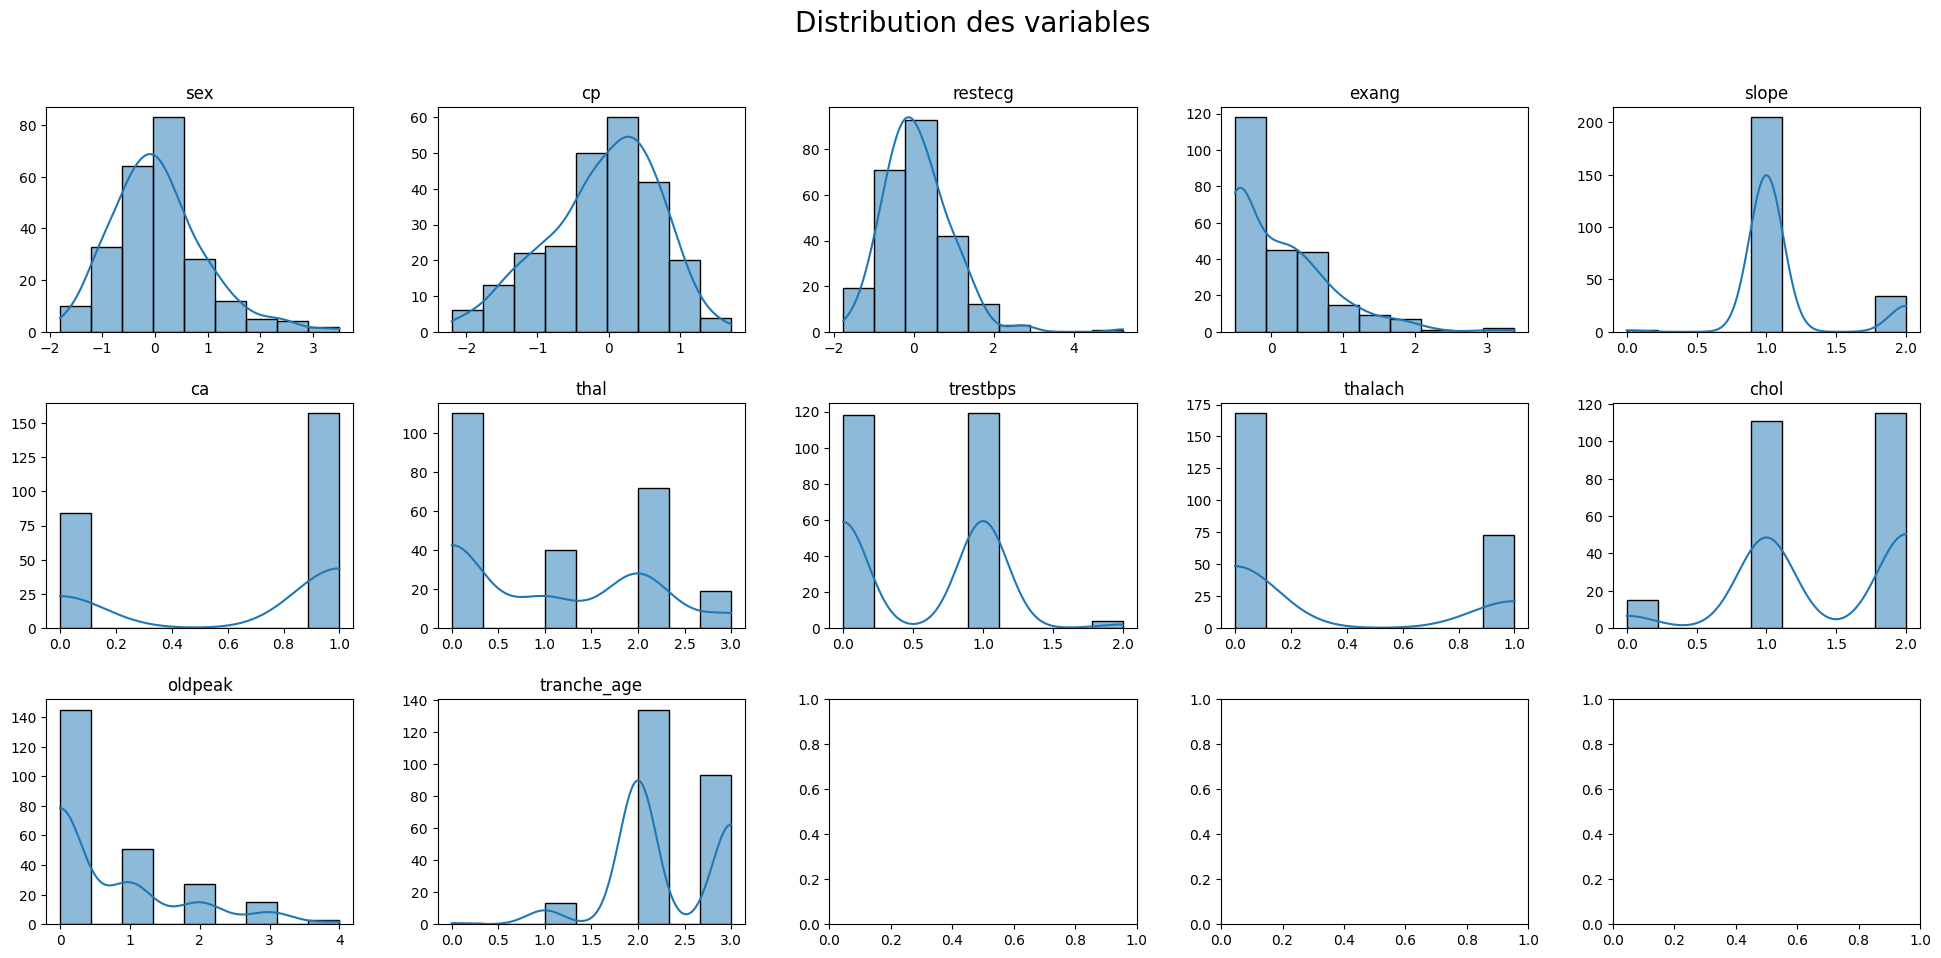

In [65]:
fig, axes = plt.subplots(3, 5, figsize=(20, 10))
fig.suptitle('Distribution des variables', fontsize=20)
fig.tight_layout(pad=3.0)

for i, col in enumerate(df_transformed[1:]):
    sns.histplot(df_transformed, x=col, bins='sturges', kde=True, ax=axes[i//5, i%5])
    axes[i//5, i%5].set_title(col)
    axes[i//5, i%5].set_xlabel('')
    axes[i//5, i%5].set_ylabel('')

plt.show()

### 4.2 - Pipeline

### Lazy classifier

In [66]:
# from lazypredict.Supervised import LazyClassifier

# # Initialiser LazyClassifier
# lazy_classifier = LazyClassifier()

# # Ajuster et évaluer les modèles
# models = lazy_classifier.fit(X_train_transformed, X_test_transformed, y_train, y_test)

# # Afficher les résultats
# print(models)

### Grid search

In [78]:
X_train['tranche_age']

132    Adulte
202    Senior
196    Senior
75     Adulte
176    Adulte
        ...  
188    Adulte
71     Adulte
106    Senior
270    Adulte
102    Adulte
Name: tranche_age, Length: 241, dtype: category
Categories (3, object): ['Jeune' < 'Adulte' < 'Senior']

In [67]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Normalisation
    ('knn', KNeighborsClassifier())  # Classificateur KNN
])

# Définir les paramètres à optimiser
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],  # Nombre de voisins
    'knn__weights': ['uniform', 'distance'],  # Poids des voisins
    'knn__metric': ['euclidean', 'manhattan']  # Métriques de distance
}

# Initialiser GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Ajuster GridSearchCV
grid_search.fit(X_train, y_train)

# Afficher les meilleurs paramètres et le meilleur score
print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score :", grid_search.best_score_)

# Évaluer le modèle sur les données de test
best_model = grid_search.best_estimator_
test_accuracy = best_model.score(X_test, y_test)
print("Accuracy sur les données de test :", test_accuracy)

Meilleurs paramètres : {'knn__metric': 'manhattan', 'knn__n_neighbors': 9, 'knn__weights': 'distance'}
Meilleur score : 0.8340986394557823
Accuracy sur les données de test : 0.8524590163934426


In [68]:
best_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   RobustScaler())]),
                                                  ['trestbps', 'thalach',
                                                   'chol', 'oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('ordinal_encoder',
                                                                   OrdinalEncoder(categories=[['Jeune',
                                                                                               'Adulte',
                                                                                               'Senior']]))]),
                                                  ['tranche_age']),
                                                 ('pass', 'passthrough',
                                                  ['sex', 'cp', 'restecg',
                                                   'exang', 'slope', 'ca',
                                                   'thal'])])),
                ('knn',
                 KNeighborsClassifier(metric='manhattan', n_neighbors=9,
                                      weights='distance'))])

In [69]:
best_model.named_steps["knn"]

KNeighborsClassifier(metric='manhattan', n_neighbors=9, weights='distance')

In [70]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# Entraînement et évaluation des modèles
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.2f}')
print(f'Precision: {precision:.2f}')
print(f'Recall: {recall:.2f}')

print('Matrice de confusion:')
print(confusion_matrix(y_test, y_pred))

print('Rapport de classification:')
print(classification_report(y_test, y_pred))
print('--------------------------------')

Accuracy: 0.85
Precision: 0.85
Recall: 0.88
Matrice de confusion:
[[24  5]
 [ 4 28]]
Rapport de classification:
              precision    recall  f1-score   support

           0       0.86      0.83      0.84        29
           1       0.85      0.88      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61

--------------------------------


### Joblib

Enregistrer le modèle dans un fichier

In [71]:
import joblib
joblib.dump(best_model, 'Cardiaque_KNN.pkl')

['Cardiaque_KNN.pkl']

Charger le modèle depuis le fichier

In [72]:
loaded_model = joblib.load('Cardiaque_KNN.pkl')

Utiliser le modèle chargé pour faire des prédictions

In [73]:
predictions = loaded_model.predict(X_test)

## Autres codes

In [74]:
# from sklearn.svm import SVC
# from sklearn.naive_bayes import GaussianNB
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.pipeline import Pipeline

# # Liste des modèles et leurs paramètres
# models = [
#     (KNeighborsClassifier(), {
#         'kneighborsclassifier__n_neighbors': [3, 5, 7, 9, 11],
#         'kneighborsclassifier__weights': ['uniform', 'distance'],
#         'kneighborsclassifier__metric': ['euclidean', 'manhattan']
#     }),
#     (SVC(), {
#         'svc__C': [0.1, 1, 10],
#         'svc__kernel': ['linear', 'rbf'],
#         'svc__gamma': ['scale', 'auto']
#     }),
#     (GaussianNB(), {})
# ]

# best_score = 0
# best_model = None

# for model, params in models:
#     pipeline = Pipeline(steps=[
#         ('preprocessor', preprocessor),  # Normalisation
#         (model.__class__.__name__.lower(), model)  # Nom du modèle en minuscules
#     ])

#     # Initialiser GridSearchCV
#     grid_search = GridSearchCV(pipeline, params, cv=5, scoring='accuracy', n_jobs=-1)

#     # Ajuster GridSearchCV
#     grid_search.fit(X_train, y_train)

#     # Afficher les meilleurs paramètres et le meilleur score
#     print(f"Meilleurs paramètres pour {model.__class__.__name__} :", grid_search.best_params_)
#     print(f"Meilleur score pour {model.__class__.__name__} :", grid_search.best_score_)

#     # Évaluer le modèle sur les données de test
#     test_accuracy = grid_search.score(X_test, y_test)
#     print(f"Accuracy sur les données de test pour {model.__class__.__name__} :", test_accuracy)

#     # Vérifier si ce modèle est le meilleur
#     if test_accuracy > best_score:
#         best_score = test_accuracy
#         best_model = grid_search.best_estimator_

# print("Meilleur modèle :", best_model)
# print("Meilleur score global :", best_score)

In [75]:
# from sklearn.svm import SVC
# from lightgbm import LGBMClassifier
# from xgboost import XGBClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.naive_bayes import GaussianNB
# from sklearn.model_selection import StratifiedShuffleSplit
# from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer, PowerTransformer
# from imblearn.under_sampling import RandomUnderSampler
# from imblearn.over_sampling import SMOTE

# # Stratified split pour obtenir des sous-échantillons équilibrés
# # Séparer les features et la target
# X = df.drop(["target"], axis=1)
# y = df['target']

# # Séparer les données en ensembles d'entraînement et de test
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
# for train_index, test_index in splitter.split(X, y):
#     X_train2, X_test2 = X.iloc[train_index], X.iloc[test_index]
#     y_train2, y_test2 = y.iloc[train_index], y.iloc[test_index]

# # Initialiser les scalers
# scalers = {
#     'MinMaxScaler': MinMaxScaler(),
#     'MaxAbsScaler': MaxAbsScaler(),
#     'StandardScaler': StandardScaler(),
#     'RobustScaler': RobustScaler(),
#     'Normalizer': Normalizer(),
#     'PowerTransformer': PowerTransformer()
# }

# # Initialiser les modèles
# models = {
#     'Logistic Regression': LogisticRegression(),
#     'Decision Tree Classifier': DecisionTreeClassifier(),
#     'Random Forest Classifier': RandomForestClassifier(),
#     'SVC': SVC(),
#     'K-Neighbors Classifier': KNeighborsClassifier(),
#     'XGBClassifier': XGBClassifier(),
#     'LGBMClassifier': LGBMClassifier(),
#     'Naive Bayes': GaussianNB()
# }

# # Dictionnaire pour stocker les résultats
# results = {scaler_name: {} for scaler_name in scalers.keys()}

# # Initialiser les variables pour suivre le meilleur modèle
# best_score = float('-inf')
# best_model = None
# best_model_name = ''
# best_scaler_name = ''

# # Fonction pour évaluer un modèle
# def evaluate_model(X_train_scaled, X_test_scaled, y_train, y_test, model):
#     model.fit(X_train_scaled, y_train)
#     y_pred = model.predict(X_test_scaled)
#     return accuracy_score(y_test, y_pred)

# # Appliquer les scalers et entraîner les modèles
# for scaler_name, scaler in scalers.items():
#     print(f'Using {scaler_name}')
#     X_train_scaled2 = scaler.fit_transform(X_train2)
#     X_test_scaled2 = scaler.transform(X_test2)

#     for model_name, model in models.items():
#         print(f'  Training {model_name}')
#         # Optionnel: Appliquer RandomUnderSampler pour gérer le déséquilibre
#         if 'Classifier' in model_name:
#             sampler = RandomUnderSampler(random_state=42)
#             X_train_resampled, y_train_resampled = sampler.fit_resample(X_train_scaled2, y_train2)
#         else:
#             X_train_resampled, y_train_resampled = X_train_scaled2, y_train2

#         score = evaluate_model(X_train_resampled, X_test_scaled2, y_train_resampled, y_test2, model)
#         results[scaler_name][model_name] = score
#         print(f'    Score for {model_name}: {score:.4f}')

#         # Mettre à jour le meilleur modèle et scaler
#         if score > best_score:
#             best_score = score
#             best_model = model
#             best_model_name = model_name
#             best_scaler_name = scaler_name

#         print('--------------------------------')

# # Afficher les résultats pour chaque scaler
# for scaler_name, model_results in results.items():
#     print(f'\nResults for {scaler_name}:')
#     for model_name, accuracy in model_results.items():
#         print(f'{model_name}: {accuracy:.4f}')

# # Afficher le meilleur modèle et scaler
# print(f'\nBest model: {best_model_name}')
# print(f'Best scaler: {best_scaler_name}')
# print(f'Best score: {best_score:.4f}')
